# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402121
- 姓名：杨孙源
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-yvetteyang3yuan
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告基于福州市二手房房源数据，围绕房源区域分布、价格水平、面积结构、户型特征、房龄差异以及变量之间的关系展开分析。分析过程中，首先使用`pandas`读取CSV数据，并对数据规模、字段类型和样例记录进行查看；随后对缺失值、重复值、异常值和字段格式问题进行检查，并对文本字段进行空格清理、数值字段类型转换，同时从户型、楼层和时间等字段中提取可分析变量。在统计分析部分，本文使用描述性统计、分组聚合、面积分段、房龄比较和相关性矩阵等方法，分析不同市区、不同户型和不同房龄条件下的房源数量与价格差异。在可视化部分，本文绘制了市区房源数量对比图、市区均价中位数对比图、均价分布 KDE图、面积与总价关系散点图、房龄均价箱线图和相关性热力图。分析结果显示，福州二手房房源主要集中在晋安和仓山，鼓楼、晋安、台江等区域均价水平相对较高；房源面积和户型规模对总价具有较明显影响，但对均价的解释作用相对有限；均价分布存在一定右偏特征，部分高均价房源会拉高平均水平；房龄与均价之间并不存在简单的“越新越贵”关系。总体来看，福州二手房价格受到区域位置、面积大小、户型结构、房龄和单位面积价格等多方面因素共同影响，不能仅依靠单一变量进行判断。

## 2. 数据读取与分析目标

本次分析使用的数据文件为`ershoufang_list.csv`，数据内容为福州市二手房房源信息。数据中每一行代表一条二手房房源记录，字段主要包括房源所在城市和市区、网站房源标题、户型、面积、方位、楼层、建造时间或房龄、小区名称、所属区域、房源链接、总价和均价等信息。

从字段类型看，数据中既包含类别型字段，也包含数值型字段。其中，市区、户型、方位、楼层、房龄、所属小区等字段可以用于分类统计和分组比较；面积数值、总价数值、均价数值等字段可以用于描述性统计、价格分布分析和变量关系分析。由于原始字段中可能存在单位字符、缺失值或格式不统一等问题，后续需要先对数据质量进行检查，并对必要字段进行清洗和类型转换。

本报告计划围绕以下几个问题展开分析：首先，观察福州市二手房房源在不同市区之间的分布情况，了解房源数量是否存在区域差异；其次，分析二手房面积、总价和均价等数值变量的基本分布特征；再次，比较不同市区、户型、方位或房龄条件下房价指标的差异；最后，结合面积、总价和均价等变量，初步观察二手房价格与房屋特征之间的关系。通过以上分析，尝试从房源分布、价格水平和房屋特征等角度对该二手房数据集进行描述性分析。

In [1]:
# 导入常用库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

#部分数据读取与字段展示
df = pd.read_csv("ershoufang_list.csv", encoding="utf-8-sig")
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况

本节主要从数据规模、字段名称、数据类型、样例数据和基础描述性统计等方面对数据集进行初步查看。通过这些操作，可以了解数据的整体结构，区分适合进行分类分析的字段与适合进行数值统计的字段，并为后续的数据质量检查、清洗处理和可视化分析提供依据。

In [2]:
# 数据规模 查看列数与行数
df.shape

(11856, 18)

>从数据规模看，本数据集共有**11856**条房源记录，包含 18 个字段。每一行代表一条二手房房源信息，每一列代表房源的某一属性，例如所在市区、户型、面积、楼层、总价、均价和房龄等。

In [3]:
# 查看所有字段名称
df.columns.tolist()

['id',
 '城市',
 '市区',
 '标题',
 '户型',
 '面积',
 '面积数值',
 '方位',
 '楼层',
 '时间',
 '所属小区',
 '所属区域',
 '房源链接',
 '总价',
 '总价数值',
 '均价',
 '均价数值',
 '房龄']

>从字段名称看，该数据主要包含房源位置、房屋基本属性和价格信息三类内容。其中，城市、市区、所属小区、所属区域 反映房源的空间位置；户型、面积、方位、楼层、时间、房龄 反映房屋的基本特征；总价、总价数值、均价、均价数值反映房源价格水平。后续分析将重点使用已经转化为数值形式的面积数值、总价数值和均价数值字段。

In [4]:
# 查看前 5 行数据，了解每个字段的具体内容形式
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


>通过查看前 5 行样例数据，可以发现部分原始字段中包含单位字符，例如`面积`字段包含“㎡”`总价`字段包含“万”，`均价`字段包含“元/㎡”。同时，数据中也已经提供了对应的数值字段，如`面积数值`、`总价数值`和`均价数值`，这些字段更适合用于后续统计分析和可视化。

In [5]:
# 字段与数据类型
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  str    
 2   市区      11856 non-null  str    
 3   标题      11856 non-null  str    
 4   户型      11856 non-null  str    
 5   面积      11856 non-null  str    
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  str    
 8   楼层      11856 non-null  str    
 9   时间      11856 non-null  str    
 10  所属小区    11856 non-null  str    
 11  所属区域    11856 non-null  str    
 12  房源链接    11856 non-null  str    
 13  总价      11830 non-null  str    
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  str    
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  str    
dtypes: float64(3), int64(1), str(14)
memory usage: 1.6 MB


>从字段类型看，`id` 为整数型字段，`面积数值`、`总价数值`、`均价数值` 为浮点型字段，可以直接进行数值统计；其余大部分字段为 object 类型，主要表示文本或类别信息，例如市区、户型、方位、楼层、所属小区和房龄等。后续进行统计和可视化时，需要根据字段含义分别选择数值型分析方法和类别型分析方法。

In [6]:
# 对数值型字段进行描述性统计
df[["面积数值", "总价数值", "均价数值"]].describe()

,面积数值,总价数值,均价数值
count,11856.000000,11830.000000,11830.00000
mean,97.888336,190.761657,19235.60093
std,25.924588,111.174039,6925.94972
min,18.000000,16.800000,2169.00000
25%,84.730000,130.000000,15298.25000
50%,93.000000,173.000000,18325.50000
75%,113.010000,225.000000,22268.50000
max,500.000000,3180.000000,92968.00000


>数值型字段的描述性统计可以反映二手房面积、总价和均价的基本分布情况，包括均值、标准差、最小值、四分位数和最大值等。通过这些统计量，可以初步判断数据是否存在明显的离散差异或极端值，为后续异常值检查和价格分析提供参考。

In [7]:
# 对主要类别型字段进行描述性统计
df[["市区", "户型", "方位", "楼层", "房龄"]].describe()

,市区,户型,方位,楼层,房龄
count,11856,11856,11856,11856,11856
unique,12,56,10,139,4
top,晋安,3 室 2 厅 2 卫,南北,高层(共33层),10年以上
freq,4350,4964,7381,257,3055


>类别型字段的描述性统计可以查看不同字段的非空数量、类别数量、出现频率最高的类别及其频数。例如，`市区`可以用于分析房源的区域分布，`户型`和`房龄`可以用于比较不同房屋特征下的价格差异。

## 4. 数据质量检查

在正式进行统计分析和可视化之前，需要先对数据质量进行检查。数据质量问题主要包括缺失值、重复值、异常值以及字段格式不统一等，避免对后续统计结果和图表展示的准确性产生不良影响。因此，本节将从缺失值、重复值、字段格式和数值异常4个方面对数据进行检查，并根据检查结果说明后续清洗思路。


In [8]:
# 缺失值检查：统计每个字段的缺失数量和缺失比例
missing_summary = pd.DataFrame({
    "缺失数量": df.isna().sum(),
    "缺失比例": df.isna().mean()
})
# 只显示存在缺失值的字段
missing_summary[missing_summary["缺失数量"] > 0]

,缺失数量,缺失比例
总价,26,0.002193
总价数值,26,0.002193
均价,26,0.002193
均价数值,26,0.002193


>从缺失值检查结果看，数据集中大部分字段不存在缺失值，仅价格相关字段存在少量缺失，主要包括 `总价`、`总价数值`、`均价` 和 `均价数值`。这些字段是后续价格分析的重要变量，因此在涉及总价和均价的统计分析时，需要对缺失记录进行处理。由于缺失数量相对于整体样本量较少，后续可以在价格分析环节对相关缺失记录进行删除，避免缺失值影响均值、分布图和分组统计结果。

In [9]:
# 检查是否存在完全重复的记录
df.duplicated().sum()

np.int64(0)

In [10]:
# 检查房源链接是否存在重复
df["房源链接"].duplicated().sum()

np.int64(0)

>完全重复值表示整行内容完全相同，而房源链接通常可以作为房源记录的唯一识别信息。因此，除了检查整行重复外，也需要进一步检查 `房源链接` 是否重复，以判断是否存在同一房源被重复记录的情况。从重复值检查结果看，数据中不存在完全重复的记录，`房源链接`字段也未发现重复值，说明每条房源记录基本可以视为一条独立样本。

In [11]:
# 查看原始字段与数值字段的对应关系
df[["面积", "面积数值", "总价", "总价数值", "均价", "均价数值"]].head()

,面积,面积数值,总价,总价数值,均价,均价数值
0,103㎡,103.0,199万,199.0,19321元/㎡,19321.0
1,83㎡,83.0,181万,181.0,21808元/㎡,21808.0
2,90㎡,90.0,159万,159.0,17667元/㎡,17667.0
3,90㎡,90.0,300万,300.0,33334元/㎡,33334.0
4,107㎡,107.0,330万,330.0,30842元/㎡,30842.0


>从字段格式看，`面积`、`总价` 和 `均价` 等原始字段包含单位字符，例如“㎡”“万”“元/㎡”。数据中已经提供了对应的数值字段，即`面积数值`、`总价数值`和`均价数值`，后续统计分析将优先使用这些数值字段。

In [12]:
# 检查关键数值字段中是否存在小于等于0的异常值
num_cols = ["面积数值", "总价数值", "均价数值"]

invalid_summary = pd.DataFrame({
    "字段名": num_cols,
    "小于等于0的数量": [(df[col] <= 0).sum() for col in num_cols],
})

invalid_summary

,字段名,小于等于0的数量
0,面积数值,0
1,总价数值,0
2,均价数值,0


>从关键数值字段检查结果看，`面积数值`、`总价数值` 和 `均价数值` 中没有明显小于等于 0 的不合理取值，说明数值字段在基本范围上较为正常。

综合以上检查结果，本数据集整体结构较为完整，未发现明显的大量缺失或重复记录。数据质量问题主要集中在价格字段的少量缺失、部分文本字段可能存在格式差异，以及数值字段中可能存在极端值。后续数据清洗将着重针对这些问题进行处理。

## 5. 数据清洗与字段转换

在前一部分的数据质量检查中，已经初步发现数据中存在少量价格字段缺失的问题。为了保证后续统计分析和可视化结果的准确性，本节在保留原始数据的基础上复制一份新数据，展开数据清洗工作，同时从原始文本字段中提取更适合分析的新变量。


In [13]:
# 复制一份数据，避免直接修改原始 df
data = df.copy()

# 查看复制后的数据前几行
data.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


>为了避免在清洗过程中直接修改原始数据，本报告先使用 `copy()` 复制一份数据，并在复制后的 `data` 数据框上进行后续处理。这样既可以保留原始数据，也便于在清洗出现问题时进行回溯。

In [14]:
# 找出所有文本型字段
object_cols = data.select_dtypes(include="object").columns

# 去除文本字段中的首尾空格和换行符
for col in object_cols:
    data[col] = data[col].astype(str).str.strip().str.replace("\n", "", regex=False)

# 查看处理后的前几行
data.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_38716\1719627491.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = data.select_dtypes(include="object").columns


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


>由于房源数据中包含较多文本字段，例如标题、户型、方位、楼层、所属小区等，这些字段在采集或整理过程中可能出现多余空格或换行符。为避免同一类别因为格式差异被识别为不同取值，本节对所有文本型字段统一去除首尾空格和换行符。

In [15]:
# 将关键数值字段统一转换为数值类型
num_cols = ["面积数值", "总价数值", "均价数值"]

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# 查看转换后的字段类型
data[num_cols].dtypes

面积数值    float64
总价数值    float64
均价数值    float64
dtype: object

>`面积数值`、`总价数值` 和 `均价数值` 是后续分析中最重要的数值字段，分别表示房源面积、总价和单位面积价格。虽然原始数据中已经提供了这些数值字段，但为了保证后续统计和可视化能够正常进行，本节仍使用 `pd.to_numeric()` 对其进行统一转换。对于无法转换的异常内容，设置为缺失值，后续在具体分析时再进行过滤。

In [16]:
# 针对价格分析，删除总价、均价、面积缺失的记录
data_price = data.dropna(subset=["面积数值", "总价数值", "均价数值"]).copy()

# 查看处理前后数据规模变化
print("清洗前数据规模：", data.shape)
print("价格分析数据规模：", data_price.shape)
print("删除记录数：", data.shape[0] - data_price.shape[0])

清洗前数据规模： (11856, 18)
价格分析数据规模： (11830, 18)
删除记录数： 26


本节单独生成与上述数值相关的 `data_price` 数据集，用于后续涉及价格和面积的分析。这样既可以避免缺失值影响统计结果，也不会直接删除原始数据中的其他信息。

In [17]:
# 从户型字段中提取室、厅、卫数量
# \s* 表示允许数字和文字之间存在任意数量的空格

data_price["室数"] = data_price["户型"].str.extract(r"(\d+)\s*室").astype(float)
data_price["厅数"] = data_price["户型"].str.extract(r"(\d+)\s*厅").astype(float)
data_price["卫数"] = data_price["户型"].str.extract(r"(\d+)\s*卫").astype(float)

# 查看提取结果
data_price[["户型", "室数", "厅数", "卫数"]].head()

,户型,室数,厅数,卫数
0,3 室 2 厅 2 卫,3.0,2.0,2.0
1,3 室 2 厅 2 卫,3.0,2.0,2.0
2,3 室 2 厅 1 卫,3.0,2.0,1.0
3,3 室 2 厅 1 卫,3.0,2.0,1.0
4,3 室 2 厅 2 卫,3.0,2.0,2.0


>`户型` 字段原本是文本格式，例如包含“几室几厅几卫”等信息。为了便于后续分析不同房间数量与房价之间的关系，本节使用正则表达式从户型字段中提取 `室数`、`厅数` 和 `卫数` 三个数值变量。转换后，原本不便直接统计的文本字段可以用于分组比较和数值分析。

In [18]:
# 从时间字段中提取建造年份
data_price["建造年份"] = data_price["时间"].str.extract(r"(\d{4})").astype(float)

# 查看提取结果
data_price[["时间", "建造年份"]].head()

,时间,建造年份
0,2025年建造,2025.0
1,2025年建造,2025.0
2,2024年建造,2024.0
3,2025年建造,2025.0
4,2024年建造,2024.0


>`时间` 字段中包含房屋建造时间或相关年份信息。为了便于后续分析房屋新旧程度与价格之间的关系，本节从该字段中提取四位数年份，生成`建造年份`变量。相比原始文本字段，年份变量更适合用于排序、分组和统计分析。

In [19]:
# 查看清洗和转换后的字段信息 data_price.info()
data_price.info()

<class 'pandas.DataFrame'>
Index: 11830 entries, 0 to 11855
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11830 non-null  int64  
 1   城市      11830 non-null  str    
 2   市区      11830 non-null  str    
 3   标题      11830 non-null  str    
 4   户型      11830 non-null  str    
 5   面积      11830 non-null  str    
 6   面积数值    11830 non-null  float64
 7   方位      11830 non-null  str    
 8   楼层      11830 non-null  str    
 9   时间      11830 non-null  str    
 10  所属小区    11830 non-null  str    
 11  所属区域    11830 non-null  str    
 12  房源链接    11830 non-null  str    
 13  总价      11830 non-null  str    
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  str    
 16  均价数值    11830 non-null  float64
 17  房龄      11830 non-null  str    
 18  室数      11830 non-null  float64
 19  厅数      11830 non-null  float64
 20  卫数      11830 non-null  float64
 21  建造年份    11830 non-null  float64
dtypes: float64(7),

本节在保留原始数据的基础上完成了数据清洗与字段转换。首先，复制原始数据，避免直接修改原始数据，在出现错误时无法追溯；其次，对文本型字段统一去除空格和换行符；再次，将面积、总价和均价等核心字段转换为数值类型，并针对价格分析生成无关键缺失值的数据集；最后，从户型和时间等文本字段中提取出室数、厅数、卫数和建造年份等新变量。经过处理后，数据更加适合进行描述性统计、分组比较和可视化分析。

## 6. 描述性统计分析

在完成数据清洗和字段转换后，本节基于清洗后的 `data_price` 数据集进行描述性统计分析。分析内容包括核心数值变量的总体统计、不同市区的房源数量与价格水平比较、不同户型和房龄条件下的价格差异、面积分段统计以及变量相关性分析。通过这些统计分析，可以从数值层面对福州二手房房源的分布特征和价格差异进行初步观察，并为后续可视化分析提供依据。


### 6.1 核心数值变量总体统计

In [20]:
# 核心数值字段的描述性统计
price_summary = data_price[["面积数值", "总价数值", "均价数值"]].describe().T
price_summary.round(2)

,count,mean,std,min,25%,50%,75%,max
面积数值,11830.0,97.84,25.90,18.0,84.56,93.0,113.0,500.0
总价数值,11830.0,190.76,111.17,16.8,130.00,173.0,225.0,3180.0
均价数值,11830.0,19235.60,6925.95,2169.0,15298.25,18325.5,22268.5,92968.0


>从总体描述性统计结果可以观察二手房面积、总价和均价的基本分布情况，包括均值、中位数、最小值、最大值和四分位数等。均值可以反映整体平均水平，中位数可以减少极端值影响，标准差可以反映数据离散程度。后续分析将结合分组统计和可视化进一步观察不同类别下的差异。

### 6.2 市区分组统计

In [21]:
# 按市区分组，统计房源数量、面积、总价和均价
district_summary = (
    data_price
    .groupby("市区")
    .agg(
        房源数量=("id", "count"),
        面积均值=("面积数值", "mean"),
        面积中位数=("面积数值", "median"),
        总价均值=("总价数值", "mean"),
        总价中位数=("总价数值", "median"),
        均价均值=("均价数值", "mean"),
        均价中位数=("均价数值", "median")
    )
    .sort_values("房源数量", ascending=False)
)

district_summary.round(2)

,房源数量,面积均值,面积中位数,总价均值,总价中位数,均价均值,均价中位数
市区,,,,,,,
晋安,4346,98.61,91.13,208.58,187.0,20524.36,20000.0
仓山,3926,99.52,97.00,180.64,173.0,17979.35,17613.5
鼓楼,1239,88.62,90.00,220.88,195.0,25083.16,22973.0
台江,906,91.61,89.73,213.04,175.0,21938.26,19763.5
闽侯,630,92.55,89.00,109.33,110.0,11698.95,12844.5
福清,219,116.29,118.15,141.11,138.0,12267.33,11819.0
连江,176,108.34,107.00,142.88,147.5,13098.03,13445.0
马尾,169,109.42,101.00,145.87,128.0,13052.51,13072.0
长乐,106,105.67,105.00,131.09,126.0,12289.05,11736.5


>市区分组统计结果可以同时反映不同区域的房源数量、面积水平和价格水平。房源数量用于观察样本在空间上的分布情况，面积和价格的均值、中位数则用于比较不同市区之间的房屋特征和价格差异。由于房价数据容易受到高价房源影响，因此本节同时保留均值和中位数，后续解释时应结合二者共同判断。

### 6.3 室数分组统计

In [22]:
# 按室数分组，统计不同户型规模下的面积和价格情况
room_summary = (
    data_price
    .dropna(subset=["室数"])
    .groupby("室数")
    .agg(
        房源数量=("id", "count"),
        面积中位数=("面积数值", "median"),
        总价中位数=("总价数值", "median"),
        均价中位数=("均价数值", "median")
    )
    .sort_index()
)

room_summary.round(2)

,房源数量,面积中位数,总价中位数,均价中位数
室数,,,,
1.0,303,45.00,85.0,19556.0
2.0,1945,73.01,131.0,18400.0
3.0,7183,92.73,175.0,17768.0
4.0,2288,124.00,240.0,20591.0
5.0,85,136.13,275.0,21349.0
6.0,19,196.00,300.0,18625.0
7.0,5,200.00,510.0,35092.0
8.0,2,410.64,2465.0,59035.0


>室数可以反映房屋户型规模。通过按室数进行分组，可以观察不同户型规模下的面积、总价和均价差异。这里主要使用中位数进行比较，是为了降低少数极端高价或大面积房源对统计结果的影响。

### 6.4 面积段统计

In [23]:
# 根据面积数值划分面积段
area_bins = [0, 60, 90, 120, 150, 200, data_price["面积数值"].max()]
area_labels = ["60㎡以下", "60-90㎡", "90-120㎡", "120-150㎡", "150-200㎡", "200㎡以上"]

data_price["面积段"] = pd.cut(
    data_price["面积数值"],
    bins=area_bins,
    labels=area_labels,
    include_lowest=True
)

# 按面积段统计房源数量和价格水平
area_summary = (
    data_price
    .groupby("面积段", observed=True)
    .agg(
        房源数量=("id", "count"),
        总价中位数=("总价数值", "median"),
        均价中位数=("均价数值", "median")
    )
)

area_summary.round(2)

,房源数量,总价中位数,均价中位数
面积段,,,
60㎡以下,666,99.0,18000.0
60-90㎡,4643,143.0,18000.0
90-120㎡,4600,190.0,18241.5
120-150㎡,1682,249.0,19528.0
150-200㎡,199,460.0,26881.0
200㎡以上,40,735.0,28588.0


>为了进一步分析不同面积区间的房源价格特征，本节将连续的面积数值划分为若干面积段。相比直接观察单个面积数值，面积分段可以更清楚地比较小面积、中等面积和大面积房源在总价和均价上的差异。这种处理方式能够增强统计结果的可解释性，也便于后续绘制分类对比图。

### 6.5 房龄统计

In [24]:
# 按房龄分组，统计不同房龄下的价格情况
age_summary = (
    data_price
    .groupby("房龄")
    .agg(
        房源数量=("id", "count"),
        面积中位数=("面积数值", "median"),
        总价中位数=("总价数值", "median"),
        均价中位数=("均价数值", "median")
    )
    .sort_values("房源数量", ascending=False)
)

age_summary.round(2)

,房源数量,面积中位数,总价中位数,均价中位数
房龄,,,,
10年以上,3055,95.60,180.0,18667.0
5-10年,3049,93.33,176.0,18477.0
2-5年,3043,90.00,178.0,18953.0
2年内,2683,90.00,134.0,15773.0


>房龄是影响二手房价格的重要房屋特征之一。通过按房龄分组，可以比较不同房龄类别下房源数量、面积和价格水平的差异。由于不同房龄类别的样本数量可能不完全相同，后续分析时需要同时关注房源数量和价格统计值，避免仅根据样本较少的类别作出过度判断。

### 6.6 相关性矩阵

In [25]:
# 选择数值变量进行相关性分析
corr_cols = ["面积数值", "总价数值", "均价数值", "室数", "厅数", "卫数",  "建造年份"]
# 只保留数据中实际存在的字段
corr_cols = [col for col in corr_cols if col in data_price.columns]
corr_matrix = data_price[corr_cols].corr()
corr_matrix.round(2)

,面积数值,总价数值,均价数值,室数,厅数,卫数,建造年份
面积数值,1.00,0.64,0.14,0.77,0.43,0.65,0.03
总价数值,0.64,1.00,0.79,0.45,0.21,0.41,-0.02
均价数值,0.14,0.79,1.00,0.08,-0.03,0.07,-0.10
室数,0.77,0.45,0.08,1.00,0.47,0.63,0.09
厅数,0.43,0.21,-0.03,0.47,1.00,0.40,0.05
卫数,0.65,0.41,0.07,0.63,0.40,1.00,0.20
建造年份,0.03,-0.02,-0.10,0.09,0.05,0.20,1.00


>相关性分析用于初步观察数值变量之间的线性关系。这里选取面积、总价、均价、室数、厅数、卫数、总楼层数和建造年份等变量构建相关系数矩阵。相关系数越接近 1，表示两个变量可能存在较强的正向关系；越接近 -1，表示可能存在较强的反向关系；接近 0 则说明线性关系较弱。需要注意的是，相关性只能说明变量之间的统计关联，不能直接说明因果关系。

综合上述描述性统计结果，可以从整体价格水平、区域分布、户型结构、面积区间、房龄差异与变量关系等方面对福州二手房数据形成初步认识。

首先，从核心数值变量的总体统计看，清洗后的数据共有 11830 条有效房源记录。房源面积均值为**97.84㎡**，中位数为**93.00㎡**，说明样本中多数房源集中在**中等面积**区间；总价均值为**190.76 万元**，中位数为**173.00万元**；均价均值为**19235.60 元/㎡**，中位数为**18325.50元/㎡**。总价和均价均表现为均值高于中位数，说明样本中可能存在部分高总价或高均价房源，对平均水平产生了一定拉动作用。

其次，从市区分组统计结果看，房源数量在不同市区之间分布并不均衡。晋安和仓山的房源数量最多，分别为4346与3926，是样本中的主要房源区域；鼓楼、台江和闽侯也具有一定样本规模。价格方面，鼓楼的均价中位数为**22973元/㎡**，在各市区中相对较高；晋安和台江的均价中位数分别为**20000元/㎡**和**19763.5元/㎡**，也处于较高水平。相比之下，罗源、永泰、平潭等区域的均价中位数较低，但这些区域的样本数量相对较少，因此解释时需要注意样本规模差异可能带来的影响。

再次，从户型室数统计结果看，三室房源数量最多，共有7183条，是本数据集中的主力户型；其次是四室房源和两室房源，分别为2288条和1945条。从面积和总价中位数看，随着室数增加，房源面积和总价整体呈上升趋势。例如，三室房源面积中位数为**92.73㎡**，总价中位数为**175万元**；四室房源面积中位数为**124㎡**，总价中位数为**240万元**。这说明户型规模扩大通常会带来更高的总价。但是，均价中位数并没有完全随着室数增加而单调上升，说明单位面积价格除了受户型规模影响外，还可能受到区域位置、房龄、交通便利性、配套设施、小区品质等因素影响。

从面积分段统计结果看，房源主要集中在**60-90㎡**和**90-120㎡**两个区间，说明中等面积房源是样本主体，随着面积段提高，总价中位数明显上升。均价方面，120㎡以下房源的均价中位数基本在**18000 元/㎡**左右，而150㎡以上房源的均价中位数明显提高，说明大面积房源不仅总价更高，单位面积价格也可能更高。不过，150㎡以上尤其是200㎡以上房源样本数量较少，后续可视化分析中可结合图表进一步观察。

从房龄分组结果看，10年以上、5-10年、2-5年和2年内四类房源的样本数量相对接近，分别为3055、3049、3043 和 2683 条。价格方面，2-5年房源的均价中位数为**18953元/㎡**，相对较高；10年以上和5-10年房源的均价中位数分别为**18667元/㎡**和**18477元/㎡**，差异不大；2年内房源的均价中位数为**15773元/㎡**，反而相对较低。这说明在当前样本中，房龄与均价之间并不是简单的“越新越贵”关系，可能还受到区域分布、房源面积结构和小区位置等因素共同影响。

最后，从相关性矩阵看，总价数值与均价数值的相关系数为**0.79**，与面积数值的相关系数为**0.64**，说明房源总价同时受到单位面积价格和房屋面积的影响。面积数值与室数的相关系数为**0.77**，与卫数的相关系数为**0.65**，说明户型规模越大，房屋面积通常也越大。相比之下，均价数值与面积数值、室数、厅数、卫数之间的相关系数较低，说明单位面积价格并不主要由户型规模决定，更可能与区域、地段、房龄和小区等因素有关。总体来看，本数据集中的福州二手房房源呈现出较明显的区域差异、面积结构差异和价格层次差异。


## 7. 可视化分析

本节基于清洗后的 `data_price` 数据集进行可视化分析。图表主要围绕房源区域分布、区域价格差异、均价分布、面积与总价关系、房龄与均价差异以及变量相关性展开。每张图表对应一个明确的分析问题，并在图表中设置标题、坐标轴标签和必要的图例说明。

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# 设置 seaborn 基础风格
sns.set_theme(style="whitegrid")

# 自动查找当前电脑可用的中文字体
available_fonts = {f.name for f in font_manager.fontManager.ttflist}

font_candidates = [
    "Microsoft YaHei",   # Windows 常见：微软雅黑
    "SimHei",            # Windows 常见：黑体
    "SimSun",            # Windows 常见：宋体
    "Arial Unicode MS"   # Mac 常见
]

for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.sans-serif"] = [font]
        break

# 解决负号显示为方块的问题
plt.rcParams["axes.unicode_minus"] = False

# 渐变色方案
blue_palette = "Blues"       # 蓝色渐变
green_palette = "Greens"     # 绿色渐变
blue_green_palette = "GnBu"  # 蓝绿色渐变

### 图1：不同区域房源数量对比

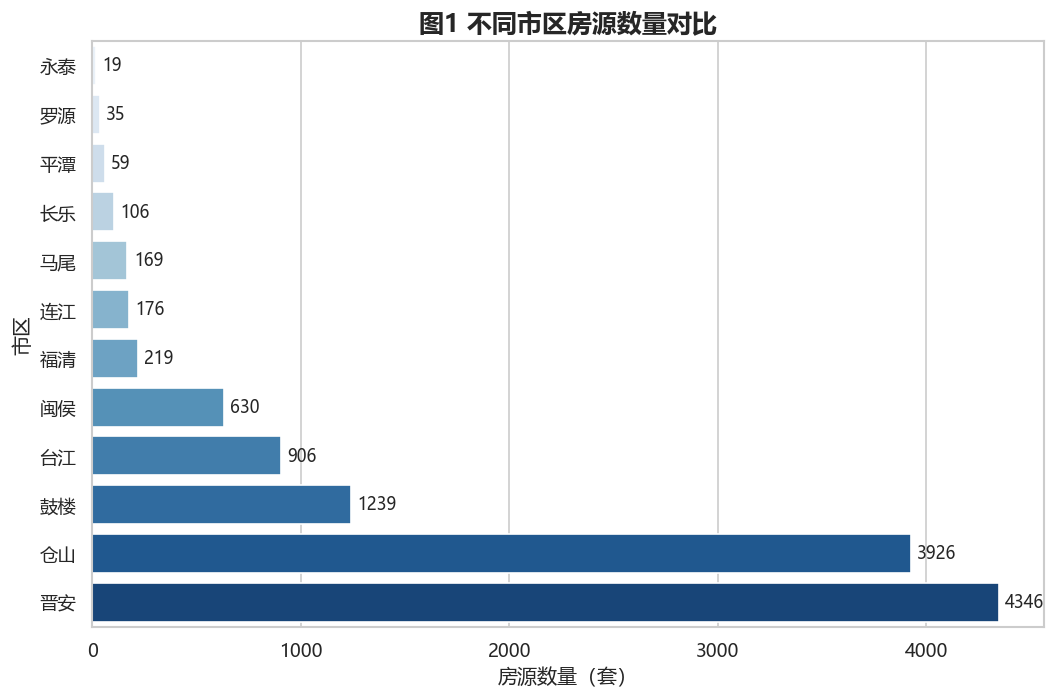

In [27]:
# 图1 不同市区房源数量对比：蓝色渐变横向柱状图
district_count = (
    data_price["市区"]
    .value_counts()
    .sort_values(ascending=True)
    .reset_index()
)
district_count.columns = ["市区", "房源数量"]
plt.figure(figsize=(9, 6), dpi=120)
sns.barplot(
    data=district_count,
    x="房源数量",
    y="市区",
    hue="市区",
    palette=sns.color_palette("Blues", len(district_count)),
    legend=False
)
plt.title("图1 不同市区房源数量对比", fontsize=15, fontweight="bold")
plt.xlabel("房源数量（套）", fontsize=12)
plt.ylabel("市区", fontsize=12)
# 添加数值标签
for i, value in enumerate(district_count["房源数量"]):
    plt.text(value + 30, i, str(value), va="center", fontsize=10)
plt.tight_layout()
plt.show()

>福州二手房房源数量在不同市区之间分布明显不均衡，其中晋安和仓山的房源数量最多，分别达到4346套和3926套，远高于其他区域。鼓楼、台江、闽侯等区域也有一定房源规模，而永泰、罗源、平潭等区域样本数量较少。说明本数据集中的房源主要集中在福州主城区或房源活跃度较高的区域，后续区域价格比较时需要注意样本数量差异。

### 图2：不同区域均价中位数对比

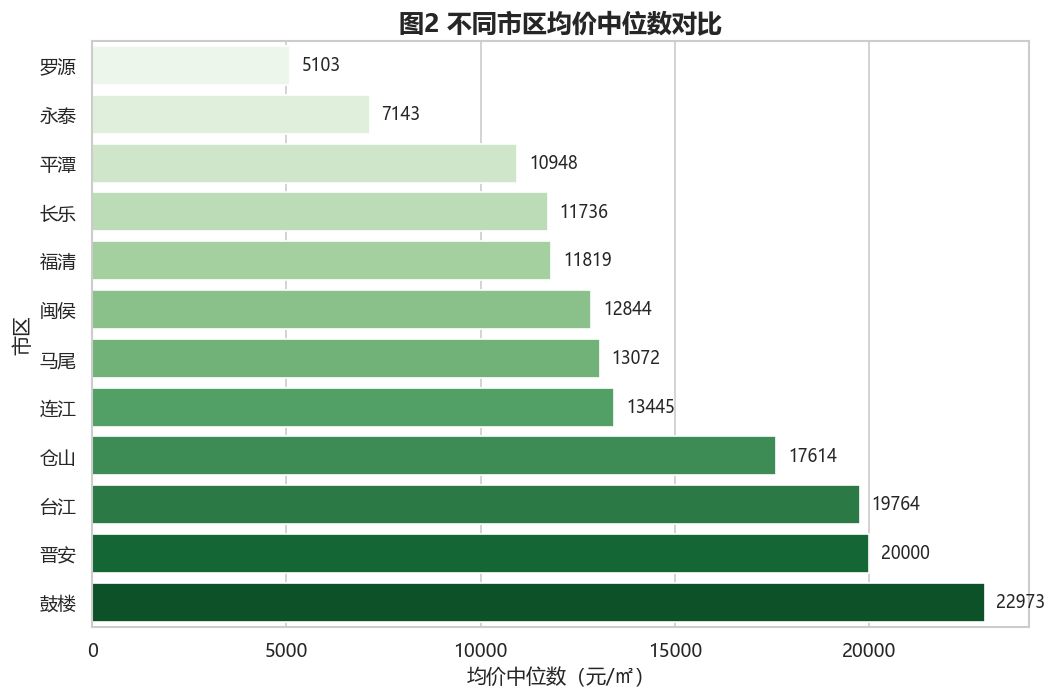

In [28]:
# 图2 不同市区均价中位数对比
district_median_price = (
    data_price
    .groupby("市区")["均价数值"]
    .median()
    .sort_values(ascending=True)
    .reset_index()
)
district_median_price.columns = ["市区", "均价中位数"]

plt.figure(figsize=(9, 6), dpi=120)

sns.barplot(
    data=district_median_price,
    x="均价中位数",
    y="市区",
    hue="市区",
    palette=sns.color_palette("Greens", len(district_median_price)),
    legend=False
)

plt.title("图2 不同市区均价中位数对比", fontsize=15, fontweight="bold")
plt.xlabel("均价中位数（元/㎡）", fontsize=12)
plt.ylabel("市区", fontsize=12)

# 添加数值标签
for i, value in enumerate(district_median_price["均价中位数"]):
    plt.text(value + 300, i, f"{value:.0f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

>不同市区的二手房均价中位数存在明显差异。鼓楼的均价中位数最高，约为22973元/㎡；晋安、台江等区域也处于较高水平，而罗源、永泰等区域均价相对较低。结合图1可以发现，房源数量最多的区域并不一定是均价最高的区域，说明二手房价格水平不仅与房源数量有关，更可能受到地段、配套和区域发展水平等因素影响。

### 图3：福州二手房均价分布KDE图

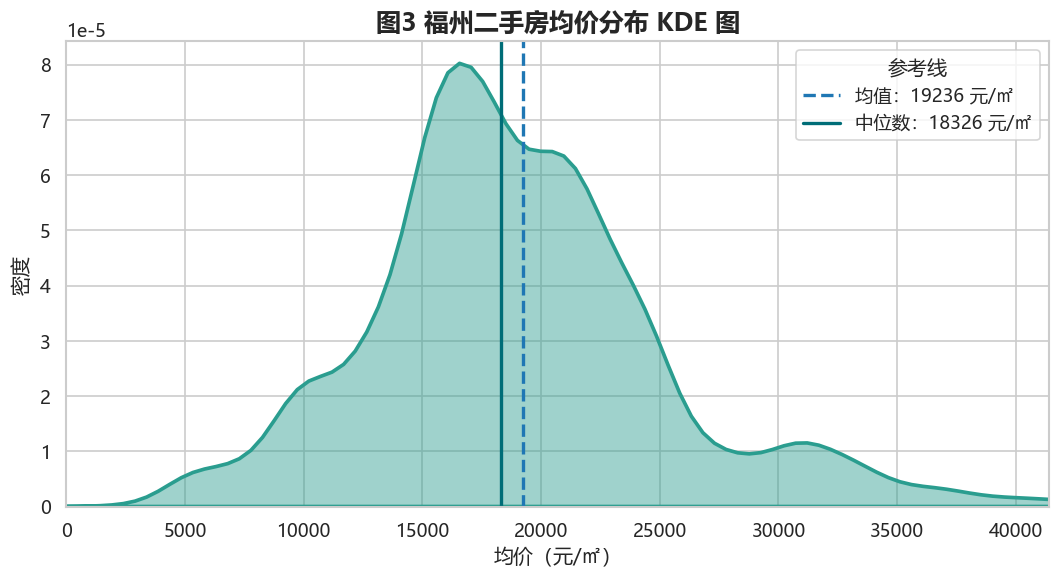

In [29]:
unit_price = data_price["均价数值"].dropna()
# 限制显示到99%分位数，便于观察主体分布，不改变原始数据
upper_limit = unit_price.quantile(0.99)

plt.figure(figsize=(9, 5), dpi=120)

sns.kdeplot(
    x=unit_price,
    fill=True,
    linewidth=2.2,
    color="#2A9D8F",
    alpha=0.45
)

# 均值参考线
plt.axvline(
    unit_price.mean(),
    color="#1F77B4",
    linestyle="--",
    linewidth=2,
    label=f"均值：{unit_price.mean():.0f} 元/㎡"
)

# 中位数参考线
plt.axvline(
    unit_price.median(),
    color="#006D77",
    linestyle="-",
    linewidth=2,
    label=f"中位数：{unit_price.median():.0f} 元/㎡"
)
plt.xlim(0, upper_limit)
plt.title("图3 福州二手房均价分布 KDE 图", fontsize=15, fontweight="bold")
plt.xlabel("均价（元/㎡）", fontsize=12)
plt.ylabel("密度", fontsize=12)
plt.legend(title="参考线")

plt.tight_layout()
plt.show()

>福州二手房均价主要集中在约15000—25000元/㎡之间，整体呈现出右侧拖尾的分布特征。图中均值约为 19236元/㎡，高于中位数约18326元/㎡，说明部分高均价房源对平均值产生了拉动作用。因此，在描述福州二手房典型均价水平时，中位数比均值更能代表多数房源的价格情况。

### 图4：面积与总价关系散点图

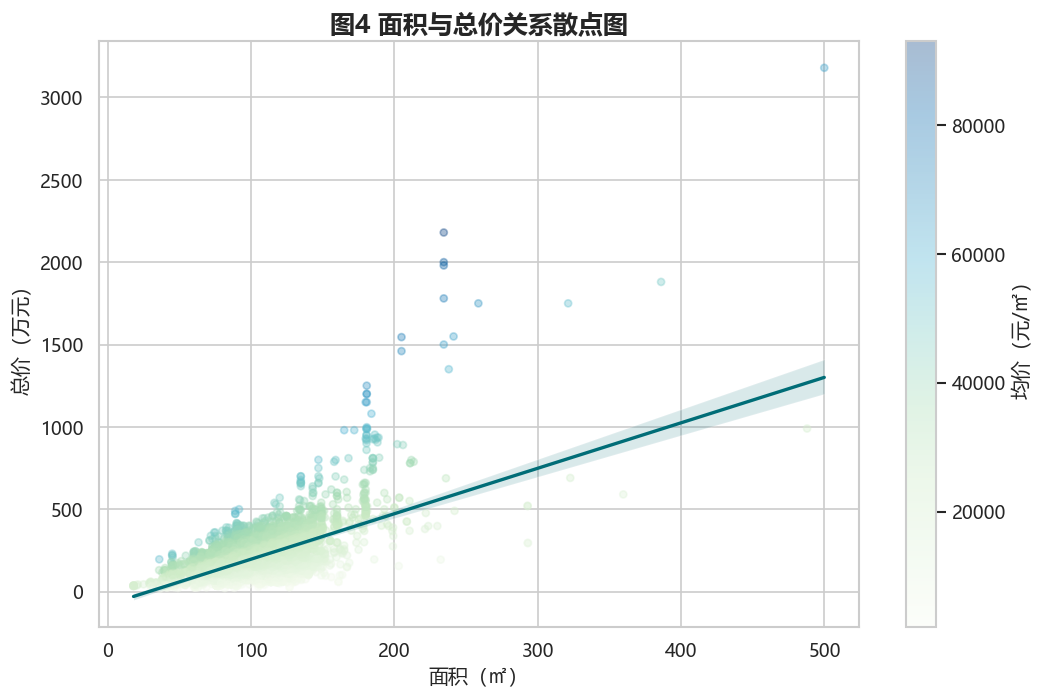

In [30]:
# 图4 面积与总价关系散点图
plot_data = data_price.dropna(subset=["面积数值", "总价数值", "均价数值"])
plt.figure(figsize=(9, 6), dpi=120)

scatter = plt.scatter(
    plot_data["面积数值"],
    plot_data["总价数值"],
    c=plot_data["均价数值"],
    cmap="GnBu",
    alpha=0.35,
    s=18
)
# 添加趋势线
sns.regplot(
    data=plot_data,
    x="面积数值",
    y="总价数值",
    scatter=False,
    color="#006D77",
    line_kws={"linewidth": 2}
)
# 添加颜色条，说明颜色代表均价
cbar = plt.colorbar(scatter)
cbar.set_label("均价（元/㎡）")

plt.title("图4 面积与总价关系散点图", fontsize=15, fontweight="bold")
plt.xlabel("面积（㎡）", fontsize=12)
plt.ylabel("总价（万元）", fontsize=12)

plt.tight_layout()
plt.show()

>面积和总价整体呈正向关系，即面积越大的房源通常总价越高，这与前面相关性分析中面积与总价存在正相关的结果一致。散点颜色表示均价水平，可以看到即使面积接近，不同房源的总价仍然存在差异，说明总价不仅受到面积影响，也受到单位面积价格差异的影响。图中少数大面积、高总价房源较为突出，说明二手房市场中存在一定的高端或特殊房源。

### 图5：不同房龄下均价分布箱线图

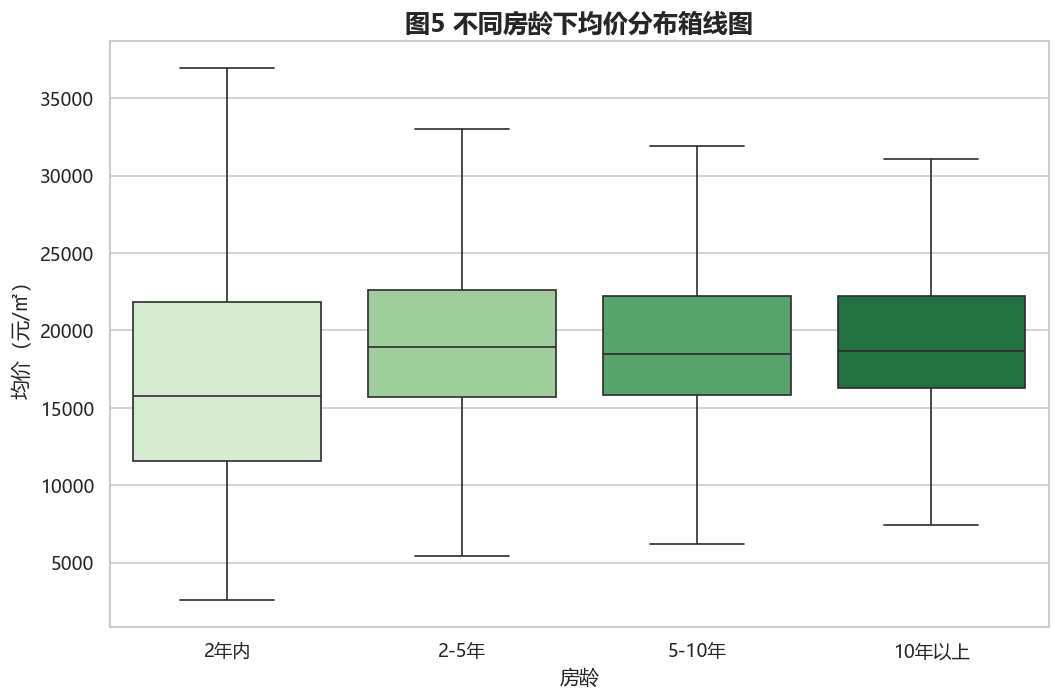

In [31]:
# 图5 不同房龄下均价分布箱线图
age_order = ["2年内", "2-5年", "5-10年", "10年以上"]
age_order = [age for age in age_order if age in data_price["房龄"].dropna().unique()]

plt.figure(figsize=(9, 6), dpi=120)

sns.boxplot(
    data=data_price,
    x="房龄",
    y="均价数值",
    order=age_order,
    hue="房龄",
    palette=sns.color_palette("Greens", len(age_order)),
    showfliers=False,
    legend=False
)

plt.title("图5 不同房龄下均价分布箱线图", fontsize=15, fontweight="bold")
plt.xlabel("房龄", fontsize=12)
plt.ylabel("均价（元/㎡）", fontsize=12)

plt.tight_layout()
plt.show()

>不同房龄房源的均价分布存在一定差异，但并不是简单的“房龄越新，均价越高”。其中，2年内房源的中位数位置并不明显高于其他房龄组，反而整体分布相对偏低；2-5年、5-10年和10年以上房源的均价分布较为接近。说明房龄并不是影响均价的唯一因素，区域位置、小区品质、面积结构等因素也可能共同影响二手房均价。

### 图6：数值变量相关性矩阵热力图

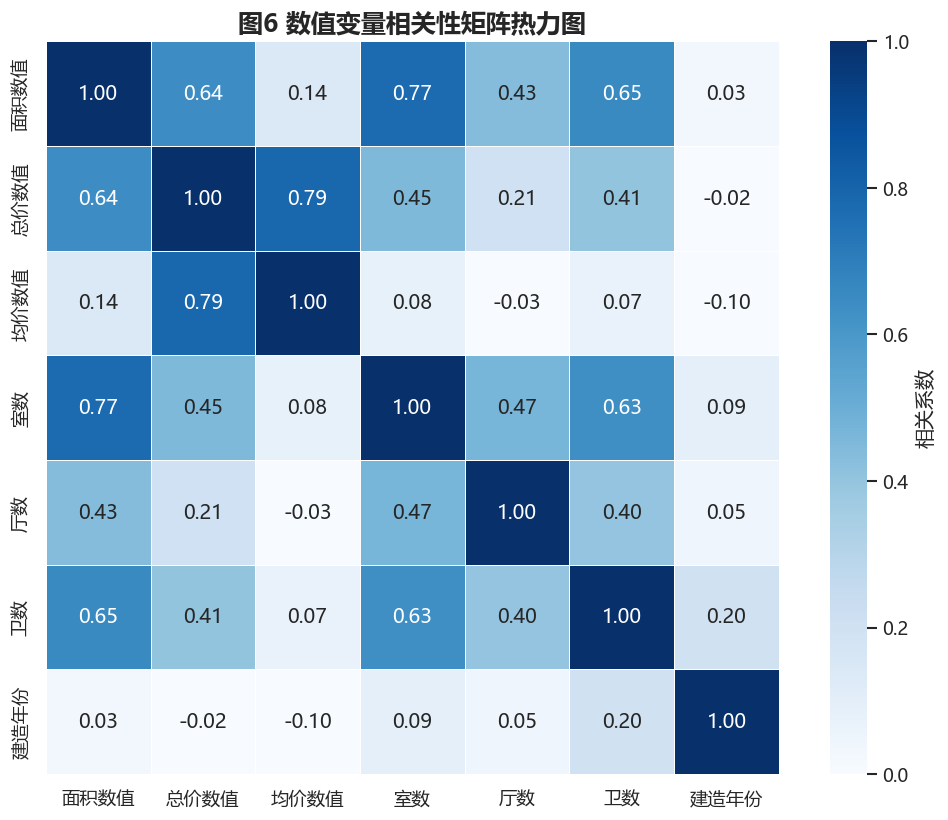

In [32]:
# 图6 数值变量相关性矩阵热力图
corr_cols = ["面积数值", "总价数值", "均价数值", "室数", "厅数", "卫数", "建造年份"]
corr_cols = [col for col in corr_cols if col in data_price.columns]
corr_matrix = data_price[corr_cols].corr()
plt.figure(figsize=(9, 7), dpi=120)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "相关系数"}
)
plt.title("图6 数值变量相关性矩阵热力图", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

>总价数值与均价数值的相关系数为 0.79，与面积数值的相关系数为 0.64，说明房源总价同时受到单位面积价格和房屋面积的影响。面积数值与室数、卫数之间也存在较强正相关，说明户型规模越大，房屋面积通常也越大。相比之下，均价数值与室数、厅数、卫数等户型变量的相关性较弱，说明单位面积价格可能更多受到区域、地段、房龄和小区条件等因素影响。

## 8. 主要结论

基于前文的数据清洗、描述性统计和可视化分析，本研究报告对福州市二手房房源数据进行了较为系统的描述性分析。总体来看，该数据集中的二手房房源在区域分布、价格水平、面积结构和房屋特征方面均呈现出一定差异，主要结论如下。

第一，福州二手房房源在不同市区之间分布不均，晋安和仓山是样本中房源数量最集中的区域，明显高于其他市区。可视化结果也进一步说明，这两个区域在本数据集中占据较高比例。该现象可能与区域居住人口规模、住宅小区数量、二手房挂牌活跃度等因素有关，也说明在进行区域价格比较时，不能忽视不同市区之间样本数量的差异。

第二，不同市区的二手房均价水平存在明显差异，区域因素是影响房价的重要维度。从均价中位数看，鼓楼约为22973元/㎡，在各市区中处于较高水平；晋安和台江的均价中位数也相对较高，分别约为20000元/㎡和19764元/㎡。相比之下，罗源、永泰、平潭等区域均价中位数较低。结合福州城市空间结构来看，鼓楼、台江等区域通常具有较成熟的城市配套和较高的中心区属性，学区密集，资源丰富，而部分外围区域价格相对较低，这与二手房市场中“地段和配套影响价格”的一般规律较为一致。

第三，房源面积和户型规模对总价具有较明显影响，但对均价的影响相对有限。描述性统计显示，房源面积均值为97.84㎡，中位数为93.00㎡，多数房源集中在中等面积区间。从室数分组结果看，三室房源数量最多，是样本中的主力户型；随着室数增加，面积中位数和总价中位数整体上升。散点图和相关性分析也显示，面积与总价存在较明显的正相关关系，相关系数为0.64。但是，均价与面积、室数、厅数、卫数之间的相关性较弱，说明单位面积价格并不主要由户型规模决定，还受到区域位置、房龄、小区品质等因素共同影响。

第四，福州二手房均价分布存在一定右偏特征，高价房源会拉高平均水平。统计结果显示，均价均值为 19235.60元/㎡，中位数为 18325.50元/㎡，均值高于中位数；KDE 分布图中也可以看到右侧存在一定高价尾部。这说明部分高均价房源对整体平均值产生了拉动作用。因此，在描述福州二手房的一般价格水平时，中位数比均值更能反映多数房源的典型情况，后续如果进行购房参考或市场比较，也应避免只根据平均价格作判断。

第五，房龄与均价之间并不是简单的“越新越贵”关系。分组统计显示，2-5年房源的均价中位数相对较高，而2年内房源的均价中位数反而较低。箱线图也表明，不同房龄组之间存在价格分布差异，但并没有呈现出房龄越短、均价越高的单调关系。这说明在二手房市场中，房龄只是影响价格的因素之一，房源所在区域、周边配套、小区品质、面积结构和挂牌房源类型等因素也可能产生重要影响。

综合来看，本次分析表明，福州市二手房价格并不是由单一因素决定的，而是受到区域位置、面积大小、户型结构、房龄和单位面积价格等多方面因素共同影响。其中，区域差异和价格结构差异较为突出，面积对总价影响明显，但对均价的解释作用有限。对于二手房市场分析而言，仅观察单个变量容易得出片面判断，更合理的方式是结合区域、房屋属性和价格指标进行综合分析。

需要说明的是，本次分析主要基于给定CSV数据进行描述性统计和可视化分析，结论只反映当前样本数据所呈现的特征。由于数据可能受到采集时间、挂牌平台、样本覆盖范围和字段完整性等因素影响，本文结论不能直接等同于整个福州二手房市场的完整情况。同时，本报告没有引入成交价格、成交周期、学区、地铁距离、商圈配套等更细致变量，因此对于房价形成机制的解释仍有一定局限。后续若能结合更完整的成交数据和空间配套信息，可以进一步提高分析的准确性和现实解释力。